# Multiclass Network Intrusion Detection (CIC-IDS2017)

This notebook trains and compares two models on six grouped CIC-IDS2017 categories: **Benign, BruteForce, DDoS, DoS, OtherAttack, and PortScan**. It uses a stratified held-out test split: each known category appears in both training and test data.

The Random Forest is saved for the Streamlit live-monitor application. The MLP is the neural-network comparison.

In [1]:
from pathlib import Path
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data' / 'cicids2017'
MODEL_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
MAX_PER_CLASS, RANDOM_STATE = 25_000, 42
CATEGORIES = ('Benign', 'BruteForce', 'DDoS', 'DoS', 'OtherAttack', 'PortScan')
tf.keras.utils.set_random_seed(RANDOM_STATE)
print('Project:', PROJECT_ROOT)

Project: c:\Project\Realtime-IDS-GitHub


In [2]:
def canonical_name(name):
    name = name.strip().lower().replace('forward', 'fwd').replace('backward', 'bwd').replace('packets', 'packet')
    return re.sub(r'[^a-z0-9]+', '_', name).strip('_')

IDENTIFIERS = {'flow_id', 'src_ip', 'dst_ip', 'source_ip', 'destination_ip', 'src_port', 'dst_port', 'source_port', 'destination_port', 'timestamp', 'label', 'target'}

def group_label(label):
    label = str(label).strip().lower()
    if label == 'benign': return 'Benign'
    if label == 'ddos': return 'DDoS'
    if label == 'portscan': return 'PortScan'
    if label.startswith('dos '): return 'DoS'
    if label in {'ftp-patator', 'ssh-patator'}: return 'BruteForce'
    return 'OtherAttack'

def collect_samples():
    files = sorted(DATA_DIR.rglob('*.csv'))
    if not files: raise FileNotFoundError(f'No CSV files found below {DATA_DIR}')
    selected, counts = {c: [] for c in CATEGORIES}, {c: 0 for c in CATEGORIES}
    for file_index, path in enumerate(files):
        print('Reading', path.name)
        for chunk_index, chunk in enumerate(pd.read_csv(path, chunksize=50_000, low_memory=False)):
            chunk.columns = [canonical_name(c) for c in chunk.columns]
            if 'label' not in chunk: raise ValueError(f'No Label column in {path.name}')
            chunk['target'] = chunk['label'].map(group_label)
            for category in CATEGORIES:
                remaining = MAX_PER_CLASS - counts[category]
                candidates = chunk[chunk['target'].eq(category)]
                if remaining <= 0 or candidates.empty: continue
                if len(candidates) > remaining:
                    candidates = candidates.sample(n=remaining, random_state=RANDOM_STATE + file_index*1000 + chunk_index)
                selected[category].append(candidates); counts[category] += len(candidates)
    return pd.concat([frame for category in CATEGORIES for frame in selected[category]], ignore_index=True)

data = collect_samples()
before = len(data); data = data.drop_duplicates().reset_index(drop=True)
print(data['target'].value_counts().sort_index())
print(f'Removed {before-len(data):,} exact duplicate rows.')

feature_columns = [c for c in data.columns if c not in IDENTIFIERS and not c.endswith('_1') and pd.api.types.is_numeric_dtype(data[c])]
X = data[feature_columns].apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
y = data['target']
X_train, X_test, y_train_text, y_test_text = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f'Features: {len(feature_columns)} | Training flows: {len(X_train):,} | Test flows: {len(X_test):,}')

Reading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Reading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Reading Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading Monday-WorkingHours.pcap_ISCX.csv
Reading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Reading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Reading Tuesday-WorkingHours.pcap_ISCX.csv
Reading Wednesday-workingHours.pcap_ISCX.csv
target
Benign         24607
BruteForce      9152
DDoS           24999
DoS            22142
OtherAttack     4143
PortScan       19917
Name: count, dtype: int64
Removed 13,068 exact duplicate rows.
Features: 76 | Training flows: 78,720 | Test flows: 26,240


## 1. Random Forest — deployed model

The imputer is fit only on the training split, then the trained model and its feature information are saved for live flow scoring.

Random Forest independent test accuracy: 99.58%
              precision    recall  f1-score   support

      Benign     0.9941    0.9894    0.9918      6152
  BruteForce     0.9987    0.9978    0.9983      2288
        DDoS     0.9997    0.9989    0.9993      6250
         DoS     0.9986    0.9980    0.9983      5535
 OtherAttack     0.9434    0.9817    0.9622      1036
    PortScan     1.0000    0.9994    0.9997      4979

    accuracy                         0.9958     26240
   macro avg     0.9891    0.9942    0.9916     26240
weighted avg     0.9959    0.9958    0.9958     26240



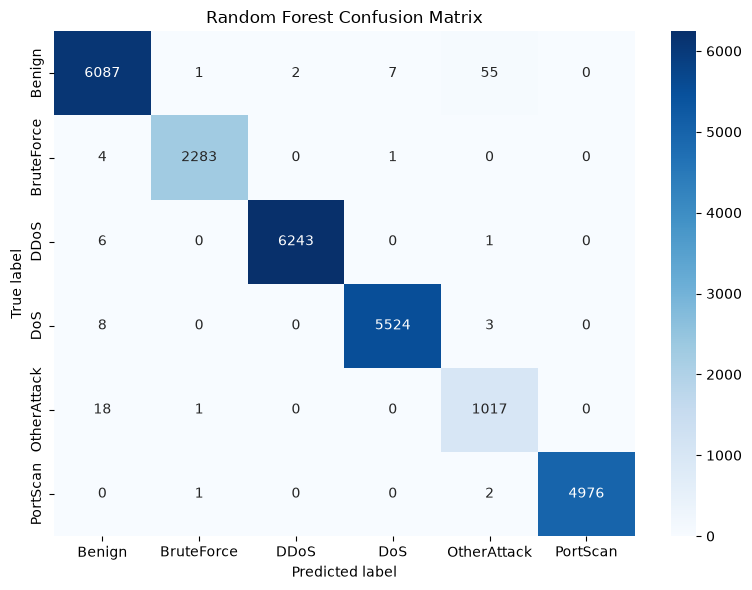

Saved deployed Random Forest: c:\Project\Realtime-IDS-GitHub\models\cicids2017_multiclass_random_forest.joblib


In [3]:
rf_imputer = SimpleImputer(strategy='median')
X_train_rf = rf_imputer.fit_transform(X_train)
X_test_rf = rf_imputer.transform(X_test)

rf_model = RandomForestClassifier(
    n_estimators=150, min_samples_leaf=2, class_weight='balanced_subsample',
    n_jobs=-1, random_state=RANDOM_STATE
)
rf_model.fit(X_train_rf, y_train_text)
rf_pred = rf_model.predict(X_test_rf)
rf_classes = list(rf_model.classes_)
print(f'Random Forest independent test accuracy: {accuracy_score(y_test_text, rf_pred):.2%}')
print(classification_report(y_test_text, rf_pred, labels=rf_classes, digits=4))

rf_matrix = confusion_matrix(y_test_text, rf_pred, labels=rf_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(rf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=rf_classes, yticklabels=rf_classes)
plt.xlabel('Predicted label'); plt.ylabel('True label'); plt.title('Random Forest Confusion Matrix'); plt.tight_layout(); plt.show()

MODEL_DIR.mkdir(exist_ok=True)
rf_path = MODEL_DIR / 'cicids2017_multiclass_random_forest.joblib'
joblib.dump({'model': rf_model, 'imputer': rf_imputer, 'feature_columns': feature_columns, 'classes': rf_classes, 'model_type': 'multiclass_known_attack_random_forest'}, rf_path)
print('Saved deployed Random Forest:', rf_path)

## 2. MLP neural-network comparison

An MLP is appropriate here because CIC-IDS2017 is tabular flow data: each flow is represented by numeric columns, not an image or time sequence.

In [4]:
mlp_imputer, scaler, encoder = SimpleImputer(strategy='median'), StandardScaler(), LabelEncoder()
X_train_mlp = scaler.fit_transform(mlp_imputer.fit_transform(X_train)).astype('float32')
X_test_mlp = scaler.transform(mlp_imputer.transform(X_test)).astype('float32')
y_train = encoder.fit_transform(y_train_text)
y_test = encoder.transform(y_test_text)
mlp_classes = list(encoder.classes_)

mlp_model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train_mlp.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Dense(len(mlp_classes), activation='softmax'),
])
mlp_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-5),
]
history = mlp_model.fit(X_train_mlp, y_train, validation_split=0.15, epochs=40, batch_size=512, callbacks=callbacks, verbose=2)

mlp_pred = mlp_model.predict(X_test_mlp, verbose=0).argmax(axis=1)
print(f'MLP independent test accuracy: {accuracy_score(y_test, mlp_pred):.2%}')
print(classification_report(y_test, mlp_pred, target_names=mlp_classes, digits=4))

Epoch 1/40
131/131 - 1s - 10ms/step - accuracy: 0.8624 - loss: 0.4452 - val_accuracy: 0.9464 - val_loss: 0.2558 - learning_rate: 0.0010
Epoch 2/40
131/131 - 1s - 4ms/step - accuracy: 0.9488 - loss: 0.1578 - val_accuracy: 0.9597 - val_loss: 0.1227 - learning_rate: 0.0010
Epoch 3/40
131/131 - 1s - 4ms/step - accuracy: 0.9608 - loss: 0.1171 - val_accuracy: 0.9739 - val_loss: 0.0887 - learning_rate: 0.0010
Epoch 4/40
131/131 - 1s - 4ms/step - accuracy: 0.9673 - loss: 0.0974 - val_accuracy: 0.9745 - val_loss: 0.0747 - learning_rate: 0.0010
Epoch 5/40
131/131 - 1s - 4ms/step - accuracy: 0.9713 - loss: 0.0851 - val_accuracy: 0.9759 - val_loss: 0.0672 - learning_rate: 0.0010
Epoch 6/40
131/131 - 1s - 4ms/step - accuracy: 0.9750 - loss: 0.0757 - val_accuracy: 0.9776 - val_loss: 0.0605 - learning_rate: 0.0010
Epoch 7/40
131/131 - 1s - 4ms/step - accuracy: 0.9762 - loss: 0.0696 - val_accuracy: 0.9798 - val_loss: 0.0583 - learning_rate: 0.0010
Epoch 8/40
131/131 - 1s - 4ms/step - accuracy: 0.9762 

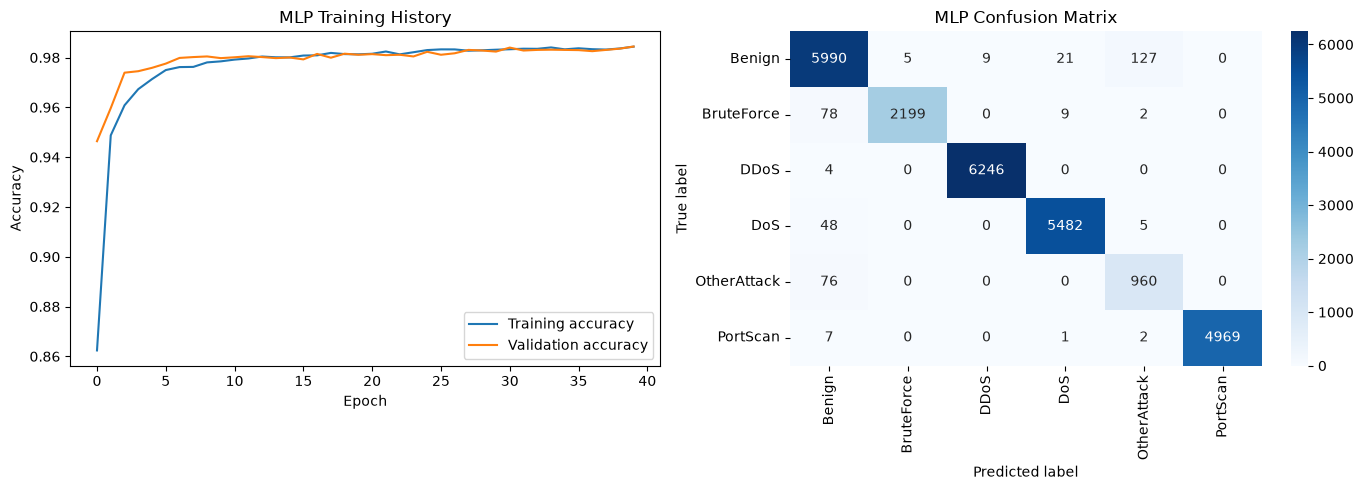

Saved MLP: c:\Project\Realtime-IDS-GitHub\models\cicids2017_multiclass_mlp.keras
Saved MLP preprocessing: c:\Project\Realtime-IDS-GitHub\models\cicids2017_multiclass_mlp_preprocessing.joblib


In [5]:
mlp_matrix = confusion_matrix(y_test, mlp_pred, labels=range(len(mlp_classes)))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Training accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[0].set(xlabel='Epoch', ylabel='Accuracy', title='MLP Training History'); axes[0].legend()
sns.heatmap(mlp_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=mlp_classes, yticklabels=mlp_classes, ax=axes[1])
axes[1].set(xlabel='Predicted label', ylabel='True label', title='MLP Confusion Matrix')
plt.tight_layout(); plt.show()

mlp_path = MODEL_DIR / 'cicids2017_multiclass_mlp.keras'
preprocess_path = MODEL_DIR / 'cicids2017_multiclass_mlp_preprocessing.joblib'
mlp_model.save(mlp_path)
joblib.dump({'imputer': mlp_imputer, 'scaler': scaler, 'feature_columns': feature_columns, 'classes': mlp_classes, 'model_type': 'multiclass_known_attack_mlp'}, preprocess_path)
print('Saved MLP:', mlp_path)
print('Saved MLP preprocessing:', preprocess_path)